# Signal Smoothing Using Ordinary Least Squares

#### Introduction

The ordinary least squares (OLS) method can be used to smooth a noisy signal—a sequence of numerical values represented by a vector $y$. The objective is to construct a new signal $x$ that remains close to the observed signal $y$ while being smoother.

A common measure of smoothness is the magnitude of the second derivative. Signals with small second derivatives vary gradually, whereas a signal with a zero second derivative is a straight line, representing the smoothest possible case. Consequently, many smoothing techniques are based on penalizing the second derivative, although other derivative operators may also be used.

Before starting the project, read the section *Signal Smoothing* in the chapter *Ordinary Least Squares* from the course textbook.

#### Objective

Implement a signal-smoothing algorithm based on the ordinary least squares method.

#### Task

Write a function that takes

- a signal vector $y$, and
- a smoothing parameter $\alpha$,

as input and returns a smoothed signal $x$.

#### Algorithm

1. Construct the finite-difference matrix $D$ that approximates the second derivative, as described in the textbook.
2. Compute the smooth signal $x$ by solving the linear system

$$
(I+\alpha D D^T)x = y.
$$

using you own linear equation solver.

#### Validation

Generate a test signal $y$ consisting of a smooth underlying signal corrupted by random noise.

Investigate the behavior of the smoothing algorithm for different values of the parameter $\alpha$ by comparing the smoothed signal $x$ with both the noisy signal and the original noise-free signal.

Verify the following limiting cases:

- As $\alpha \to 0$, the smoothed signal $x$ should converge to the noisy signal $y$.
- As $\alpha \to \infty$, the smoothed signal $x$ should converge to the best linear least-squares fit to $y$.

Illustrate your results graphically.

#### Extensions

Explore one or more practical applications of your implementation. For example, take the data for the wind speed from, say, Sletterhage Fyr weather station and smooth it. You can find the data here.

## DMI measurements

In [1]:
from pathlib import Path
import pandas as pd

data_files = sorted(Path(".").glob("tranebjerg-syd_*.csv"))

print("Found CSV files:")
for file in data_files:
    print(" -", file.name)

print("\nPreview of each file:")
for file in data_files:
    print("\n" + "="*70)
    print(file.name)
    print("="*70)

    # Try common DMI separators
    try:
        df = pd.read_csv(file, sep=";", encoding="utf-8-sig")
    except Exception:
        df = pd.read_csv(file, sep=",", encoding="utf-8-sig")

    print("Columns:")
    print(df.columns.tolist())

    print("\nFirst rows:")
    display(df.head())

Found CSV files:
 - tranebjerg-syd_L.csv
 - tranebjerg-syd_N.csv
 - tranebjerg-syd_T.csv
 - tranebjerg-syd_V.csv

Preview of each file:

tranebjerg-syd_L.csv
Columns:
['DateTime', 'Luftfugtighed']

First rows:


,DateTime,Luftfugtighed
0,2026-06-28 19:10:00,72
1,2026-06-28 19:20:00,72
2,2026-06-28 19:30:00,72
3,2026-06-28 19:40:00,72
4,2026-06-28 19:50:00,72



tranebjerg-syd_N.csv
Columns:
['DateTime', '10 minutters nedbør']

First rows:


,DateTime,10 minutters nedbør
0,2026-06-28 19:10:00,0.0
1,2026-06-28 19:20:00,0.0
2,2026-06-28 19:30:00,0.0
3,2026-06-28 19:40:00,0.0
4,2026-06-28 19:50:00,0.0



tranebjerg-syd_T.csv
Columns:
['DateTime', 'Temperatur']

First rows:


,DateTime,Temperatur
0,2026-06-28 19:10:00,25.1
1,2026-06-28 19:20:00,25.0
2,2026-06-28 19:30:00,25.1
3,2026-06-28 19:40:00,25.0
4,2026-06-28 19:50:00,25.0



tranebjerg-syd_V.csv
Columns:
['DateTime', '10 min. middelvind', 'Højeste vindstød']

First rows:


,DateTime,10 min. middelvind,Højeste vindstød
0,2026-06-28 19:10:00,4.6,6.3
1,2026-06-28 19:20:00,4.1,6.7
2,2026-06-28 19:30:00,3.6,5.4
3,2026-06-28 19:40:00,3.6,5.4
4,2026-06-28 19:50:00,3.1,5.3


# Project 

## Introduction

In this project, ordinary least-squares smoothing is used to reduce noise in measured signals. The main idea is to construct a new signal $x$ that stays close to the measured signal $y$, while also being smoother.

Smoothness is measured using the second finite difference. A signal with large second differences changes rapidly, while a signal with small second differences varies more gradually. The smoothing problem is therefore written as a balance between two requirements: the smoothed signal should stay close to the data, but it should also have small curvature.

The smoothed signal is found by solving the linear system

$$
(I+\alpha D^T D)x = y,
$$

where $D$ is the second-difference matrix and $\alpha$ is the smoothing parameter. A small value of $\alpha$ gives a solution close to the original data, while a large value of $\alpha$ gives a much smoother signal.

The method is first tested on an artificial noisy signal where the true noise-free signal is known. This makes it possible to check the limiting cases $\alpha \to 0$ and $\alpha \to \infty$. Afterwards, the method is applied to real DMI measurements from Tranebjerg Syd, including temperature, humidity, precipitation, mean wind speed, and maximum wind gust. The residual-smoothness tradeoff is then used to investigate how the choice of $\alpha$ affects the result.

## Load all datasets

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

files = sorted(Path(".").glob("tranebjerg-syd_*.csv"))

signals = {}

for file in files:
    df = pd.read_csv(file, sep=";", encoding="utf-8-sig")
    df["DateTime"] = pd.to_datetime(df["DateTime"])

    for col in df.columns:
        if col == "DateTime":
            continue

        data = df[["DateTime", col]].copy()
        data[col] = pd.to_numeric(data[col], errors="coerce")
        data = data.dropna()

        signals[col] = data.rename(columns={col: "value"})

print("Loaded signals:")
for name, data in signals.items():
    print(f"{name:25s}: {len(data)} points")

Loaded signals:
Luftfugtighed            : 144 points
10 minutters nedbør      : 144 points
Temperatur               : 144 points
10 min. middelvind       : 144 points
Højeste vindstød         : 144 points


## OLS smoothing-metoden

In [3]:
def second_difference_matrix(n):
    """
    Construct the finite-difference matrix D for the second derivative.

    For a signal x with n points, D has size (n-2) x n and computes

        x[i] - 2*x[i+1] + x[i+2].
    """
    D = np.zeros((n - 2, n))

    for i in range(n - 2):
        D[i, i] = 1.0
        D[i, i + 1] = -2.0
        D[i, i + 2] = 1.0

    return D


def gaussian_elimination_solve(A, b):
    """
    Solve A x = b using Gaussian elimination with partial pivoting.
    """
    A = np.array(A, dtype=float)
    b = np.array(b, dtype=float)

    n = len(b)

    for k in range(n):
        pivot = k + np.argmax(np.abs(A[k:, k]))

        if abs(A[pivot, k]) < 1e-14:
            raise ValueError("Matrix is singular or nearly singular.")

        if pivot != k:
            A[[k, pivot]] = A[[pivot, k]]
            b[[k, pivot]] = b[[pivot, k]]

        for i in range(k + 1, n):
            factor = A[i, k] / A[k, k]
            A[i, k:] -= factor * A[k, k:]
            b[i] -= factor * b[k]

    x = np.zeros(n)

    for i in range(n - 1, -1, -1):
        x[i] = (b[i] - A[i, i + 1:] @ x[i + 1:]) / A[i, i]

    return x


def smooth_signal(y, alpha):
    """
    Compute the OLS-smoothed signal x from

        (I + alpha D^T D)x = y.
    """
    y = np.array(y, dtype=float)
    n = len(y)

    D = second_difference_matrix(n)
    I = np.eye(n)
    A = I + alpha * D.T @ D

    x = gaussian_elimination_solve(A, y)
    return x

The linear system from the OLS smoothing problem was solved using my own Gaussian elimination solver with partial pivoting.

## Test on artificial signal

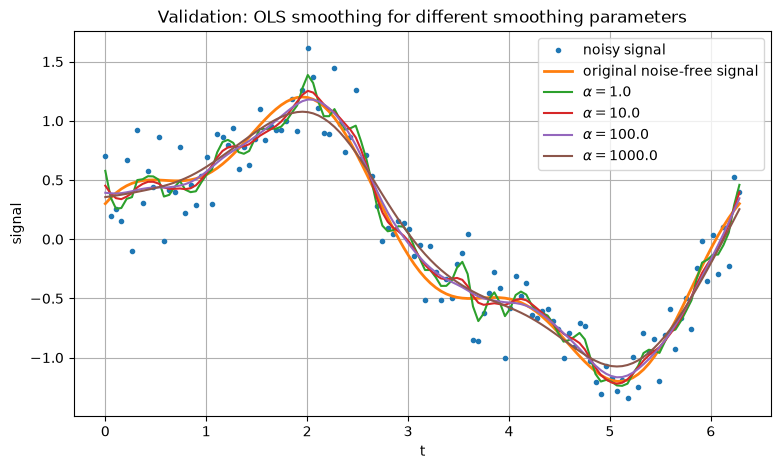

In [4]:
np.random.seed(1)

n = 120
t = np.linspace(0, 2*np.pi, n)

y_exact = np.sin(t) + 0.3*np.cos(3*t)
noise = 0.25*np.random.normal(size=n)
y_noisy = y_exact + noise

alphas = [0.0, 1.0, 10.0, 100.0, 1000.0]

plt.figure(figsize=(9, 5))
plt.plot(t, y_noisy, ".", label="noisy signal")
plt.plot(t, y_exact, linewidth=2, label="original noise-free signal")

for alpha in alphas[1:]:
    x_smooth = smooth_signal(y_noisy, alpha)
    plt.plot(t, x_smooth, label=fr"$\alpha={alpha}$")

plt.xlabel("t")
plt.ylabel("signal")
plt.title("Validation: OLS smoothing for different smoothing parameters")
plt.legend()
plt.grid(True)
plt.show()

## Limit cases

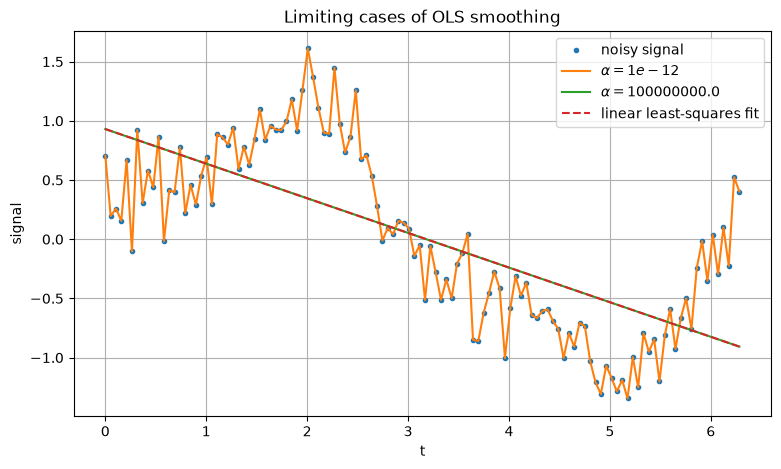

Maximum difference between noisy signal and alpha -> 0 solution:
6.520950446287088e-12

Maximum difference between large-alpha solution and linear fit:
0.0005234834620976292


In [5]:
alpha_small = 1e-12
alpha_large = 1e8

x_small = smooth_signal(y_noisy, alpha_small)
x_large = smooth_signal(y_noisy, alpha_large)

linear_fit = np.polyval(np.polyfit(t, y_noisy, 1), t)

plt.figure(figsize=(9, 5))
plt.plot(t, y_noisy, ".", label="noisy signal")
plt.plot(t, x_small, label=fr"$\alpha={alpha_small}$")
plt.plot(t, x_large, label=fr"$\alpha={alpha_large}$")
plt.plot(t, linear_fit, "--", label="linear least-squares fit")

plt.xlabel("t")
plt.ylabel("signal")
plt.title("Limiting cases of OLS smoothing")
plt.legend()
plt.grid(True)
plt.show()

print("Maximum difference between noisy signal and alpha -> 0 solution:")
print(np.max(np.abs(y_noisy - x_small)))

print("\nMaximum difference between large-alpha solution and linear fit:")
print(np.max(np.abs(x_large - linear_fit)))

## Smooth DMI-data

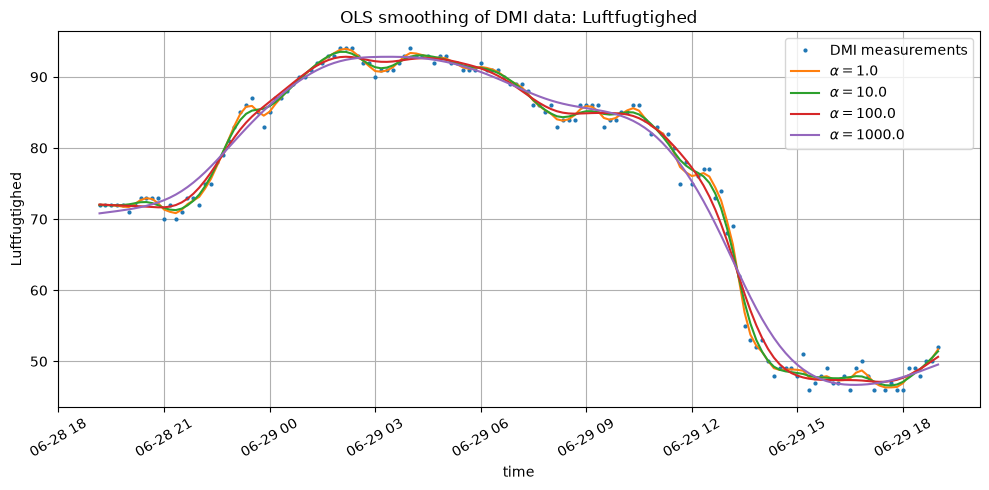

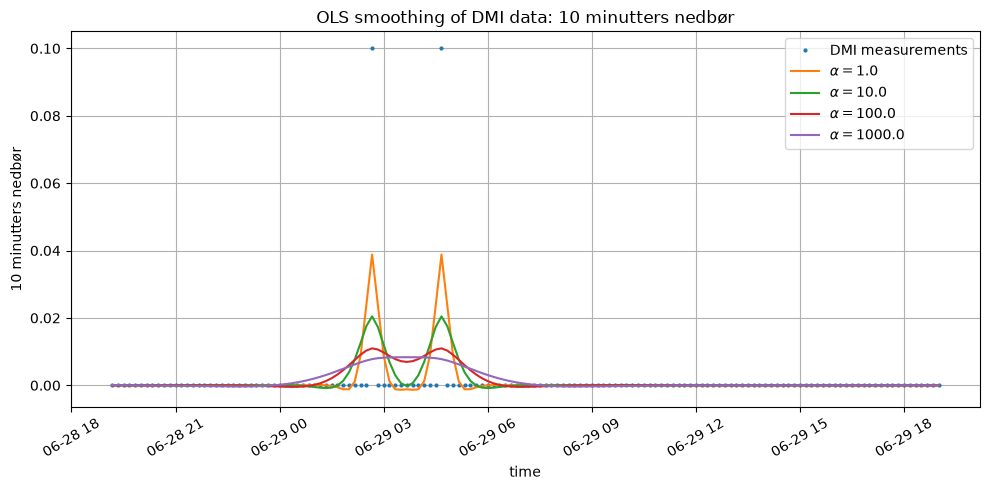

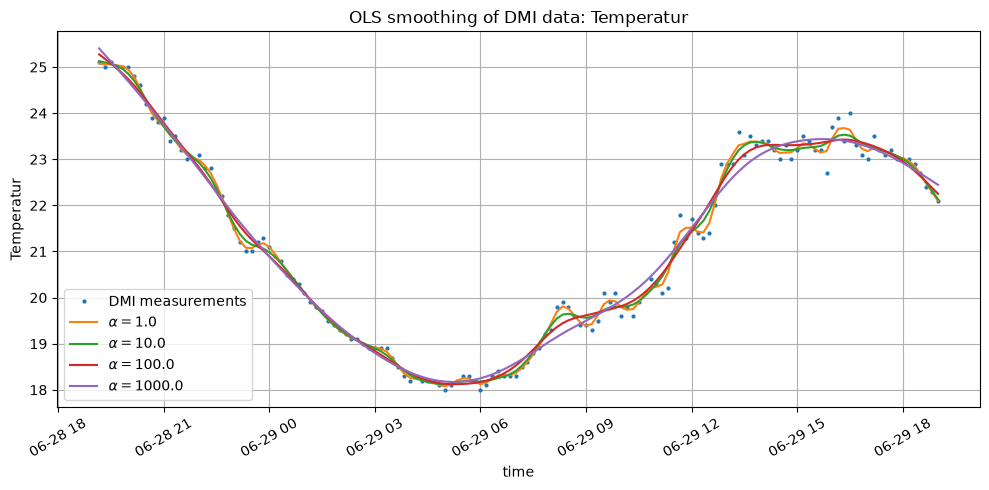

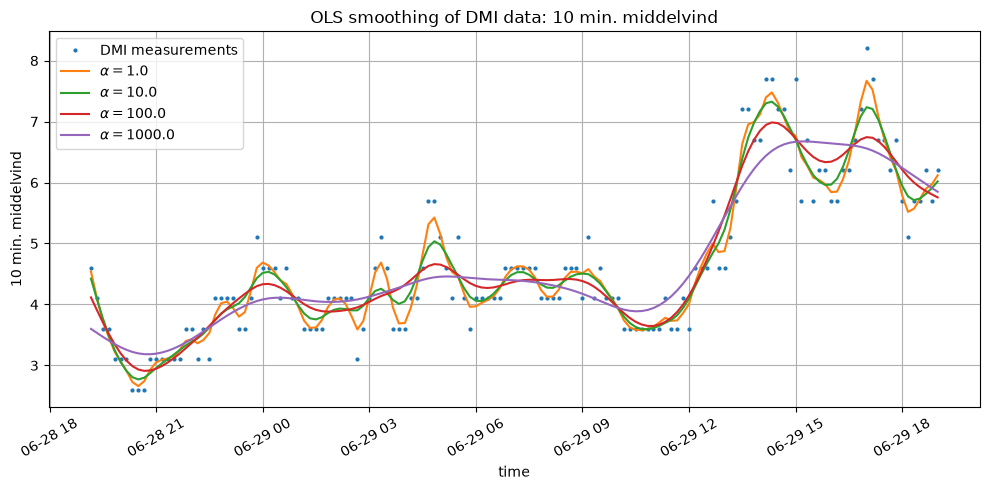

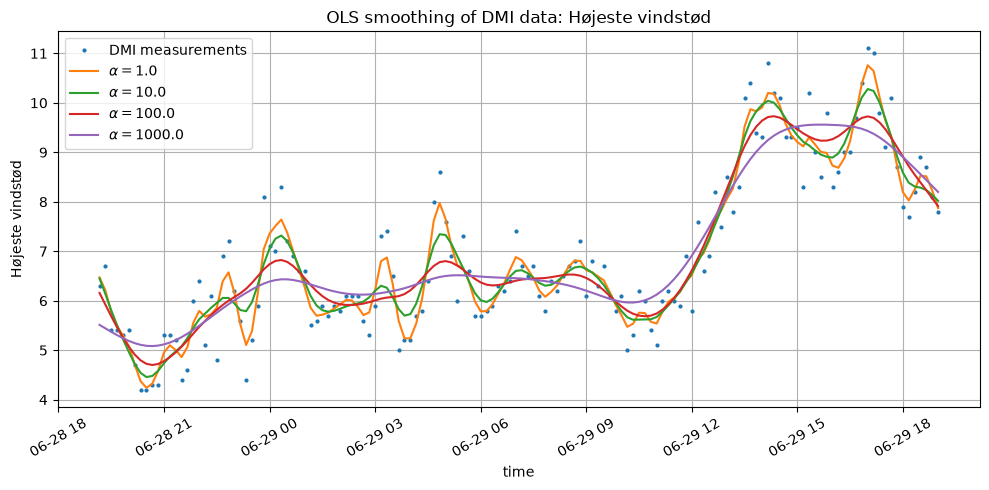

In [6]:
alpha_values = [1.0, 10.0, 100.0, 1000.0]

for name, data in signals.items():
    time = data["DateTime"]
    y = data["value"].to_numpy(dtype=float)

    plt.figure(figsize=(10, 5))
    plt.plot(time, y, ".", markersize=4, label="DMI measurements")

    for alpha in alpha_values:
        x = smooth_signal(y, alpha)
        plt.plot(time, x, label=fr"$\alpha={alpha}$")

    plt.xlabel("time")
    plt.ylabel(name)
    plt.title(f"OLS smoothing of DMI data: {name}")
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

### Note on the data interval and precipitation data

The DMI data used in this project covers only one day, with measurements every 10 minutes. This gives 144 data points for each parameter. Since the time interval is relatively short, the data only captures the weather development during this specific day.

This is especially important for the precipitation data. During the selected day, most precipitation measurements are zero, with only a few isolated nonzero values. Since the OLS smoothing method is linear and unconstrained, a single precipitation spike is spread out over nearby time points when smoothing is applied.

This means that the smoothed precipitation curve should not be interpreted as exact physical rainfall at every time point. In particular, the method may produce small artificial values around isolated rain events. For precipitation data, a constrained method that preserves non-negativity would be more physically appropriate. However, the result is still useful for illustrating how the OLS smoothing algorithm behaves on sparse data with sharp local peaks.

## Short analysis of the choice of $\alpha$

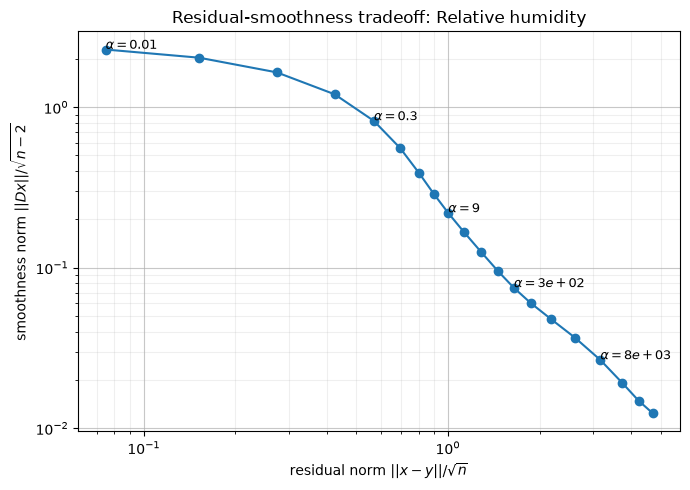

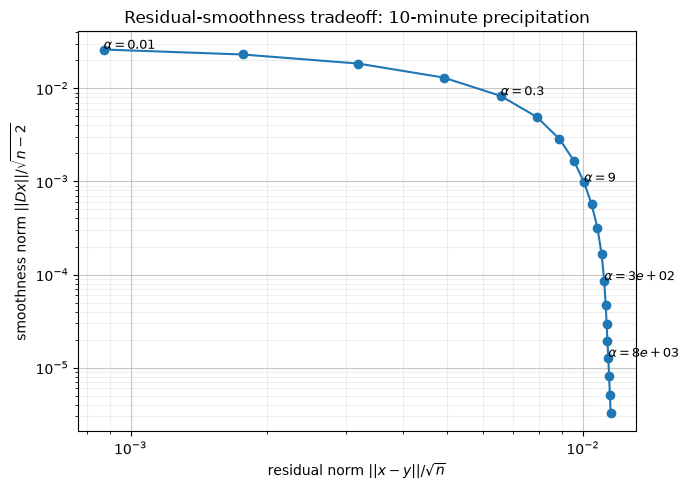

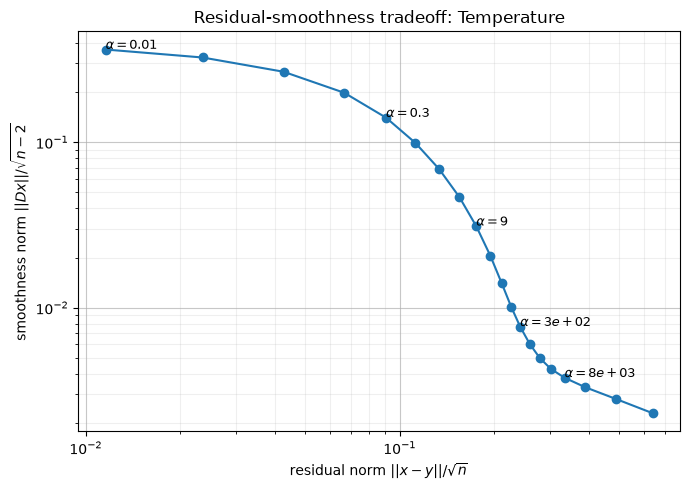

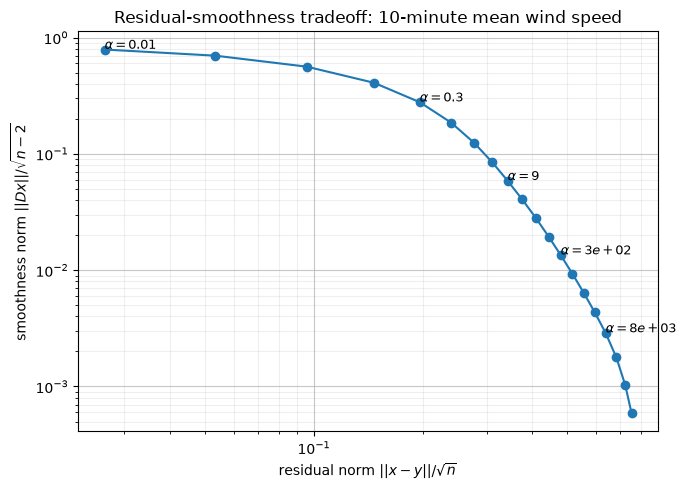

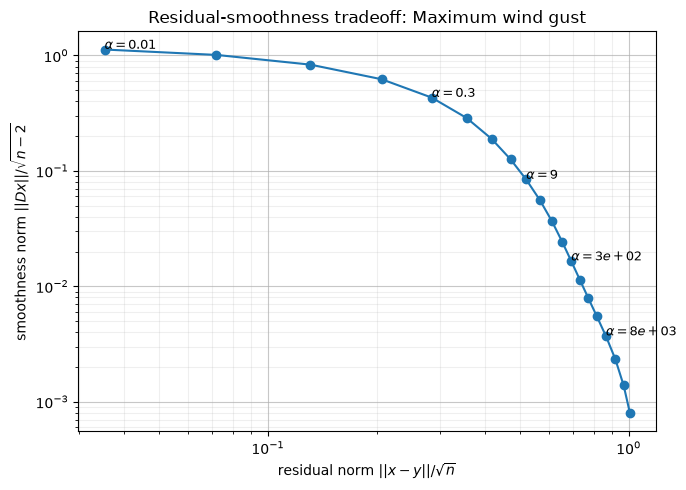

In [7]:
from matplotlib.ticker import NullFormatter

# English names for the DMI measurement parameters
english_names = {
    "Luftfugtighed": "Relative humidity",
    "10 minutters nedbør": "10-minute precipitation",
    "Temperatur": "Temperature",
    "10 min. middelvind": "10-minute mean wind speed",
    "Højeste vindstød": "Maximum wind gust",
}


def roughness_norm(x):
    """
    Measure the roughness of the smoothed signal.

    A smaller value means a smoother signal.
    """
    D = second_difference_matrix(len(x))
    return np.linalg.norm(D @ x) / np.sqrt(len(x) - 2)


def residual_norm(y, x):
    """
    Measure how far the smoothed signal x is from the measured signal y.

    A smaller value means the smoothed signal follows the data more closely.
    """
    return np.linalg.norm(y - x) / np.sqrt(len(y))


# Values of alpha used to study the residual-smoothness tradeoff
alpha_scan = np.logspace(-2, 5, 20)

for name, data in signals.items():
    y = data["value"].to_numpy(dtype=float)

    residuals = []
    roughnesses = []

    for alpha in alpha_scan:
        x = smooth_signal(y, alpha)

        residuals.append(residual_norm(y, x))
        roughnesses.append(roughness_norm(x))

    plot_name = english_names.get(name, name)

    fig, ax = plt.subplots(figsize=(7, 5))

    ax.loglog(residuals, roughnesses, marker="o")

    # Add labels for selected alpha values
    for alpha, r, s in zip(alpha_scan[::4], residuals[::4], roughnesses[::4]):
        ax.text(r, s, fr"$\alpha={alpha:.1g}$", fontsize=9)

    ax.set_xlabel(r"residual norm $||x-y||/\sqrt{n}$")
    ax.set_ylabel(r"smoothness norm $||Dx||/\sqrt{n-2}$")
    ax.set_title(f"Residual-smoothness tradeoff: {plot_name}")

    # Cleaner grid for logarithmic axes
    ax.grid(True, which="major", alpha=0.7)
    ax.grid(True, which="minor", alpha=0.2)

    # Remove cluttered minor tick labels on logarithmic axes
    ax.xaxis.set_minor_formatter(NullFormatter())
    ax.yaxis.set_minor_formatter(NullFormatter())

    plt.tight_layout()
    plt.show()

## Discussion

The ordinary least-squares smoothing method was tested on both an artificial signal and real DMI measurement data from Tranebjerg Syd. The method solves the linear system

$$
(I+\alpha D^T D)x = y,
$$

where $y$ is the measured signal, $x$ is the smoothed signal, and $D$ approximates the second derivative. The parameter $\alpha$ controls how strongly curvature is penalized.

The validation with an artificial noisy signal confirms the expected behavior of the method. For very small $\alpha$, the smoothed signal is almost identical to the noisy input signal. This is expected because the smoothing term becomes negligible, so the solution mainly minimizes the difference between $x$ and $y$. For very large $\alpha$, the solution becomes close to a straight least-squares line, since a straight line has zero second derivative and is therefore the smoothest possible solution under this penalty.

The method was then applied to five DMI measurement parameters: relative humidity, 10-minute precipitation, temperature, 10-minute mean wind speed, and maximum wind gust. For relative humidity and temperature, the smoothed curves follow the main daily trend while removing small local fluctuations. These signals are naturally fairly smooth, so the method works well and the choice of $\alpha$ mainly controls how much small-scale variation is removed.

For wind speed and wind gusts, the measurements contain more short-time fluctuations. The smoothing method still preserves the larger trend, but larger values of $\alpha$ are needed to remove the rapid variations. This is visible in the residual-smoothness tradeoff plots, where increasing $\alpha$ reduces the smoothness norm $||Dx||/\sqrt{n-2}$ while increasing the residual norm $||x-y||/\sqrt{n}$. A moderate value such as $\alpha=100$ or $\alpha=1000$ gives a reasonable compromise between following the measurements and producing a smooth signal.

The precipitation data behaves differently from the other parameters. Most values are zero, with only a few isolated nonzero measurements. Because the smoothing method is linear and does not impose non-negativity, isolated precipitation spikes are spread out over nearby time points. This can also produce small negative smoothed values, which are not physically meaningful for precipitation. Therefore, the method is useful for showing a smoothed trend, but it is not ideal for sparse non-negative signals such as precipitation unless additional constraints are included.

The residual-smoothness tradeoff plots illustrate the role of $\alpha$ clearly. Small $\alpha$ values are located in the upper-left part of the plots: the residual is small, but the roughness is large. Large $\alpha$ values are located in the lower-right part: the signal is smoother, but it differs more from the measured data. The best choice of $\alpha$ is therefore not universal, but depends on the signal and on how much smoothing is desired.


## Conclusion

The OLS smoothing algorithm was successfully implemented and tested. The limiting cases were verified: as $\alpha \to 0$, the solution approaches the original noisy signal, while for very large $\alpha$, the solution approaches a straight least-squares fit.

When applied to DMI data from Tranebjerg Syd, the method produced useful smoothed versions of temperature, humidity, wind speed, and wind gust measurements. The residual-smoothness tradeoff plots show that increasing $\alpha$ gives smoother curves at the cost of larger deviations from the measurements. For most of the DMI signals, values around $\alpha=100$ to $\alpha=1000$ give a good compromise.

The method is less suitable for precipitation data because precipitation is sparse and non-negative, while the OLS smoothing method is unconstrained and can spread isolated rain events over time. Still, the result illustrates how the smoothing algorithm behaves on different types of signals.

Overall, the project demonstrates that OLS smoothing with a second-derivative penalty is a simple and effective method for reducing noise while preserving the main structure of a signal.

## Save cell

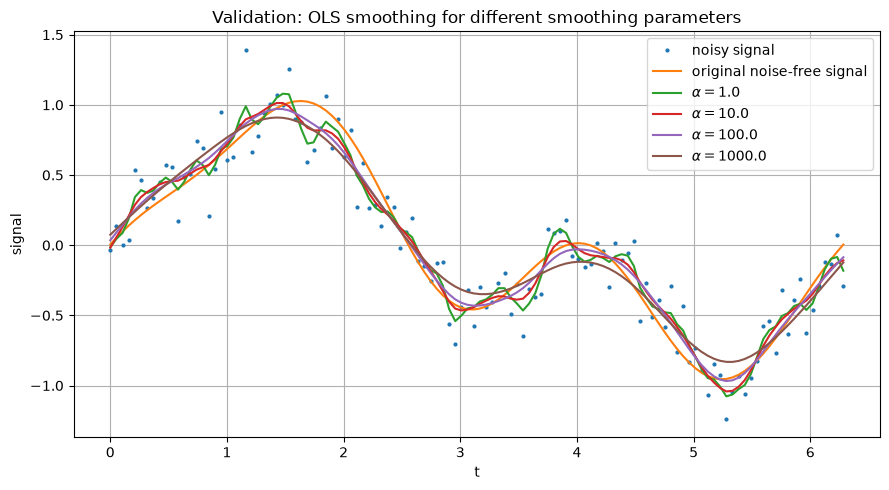

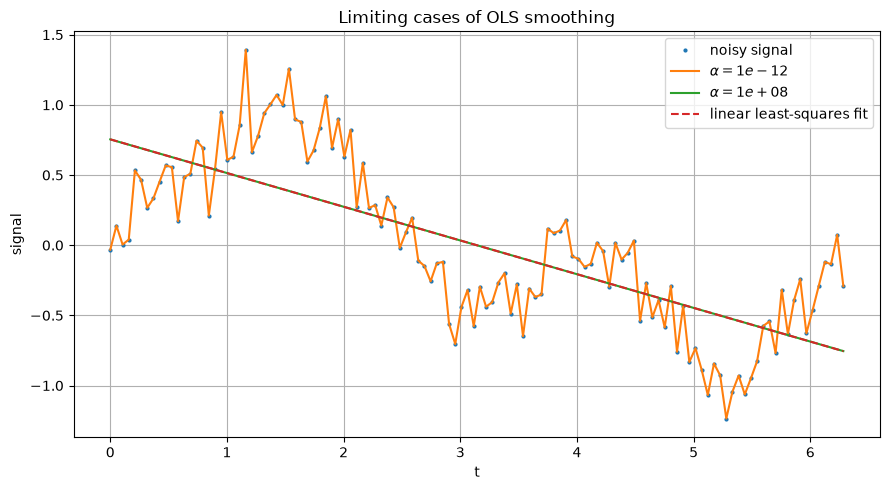

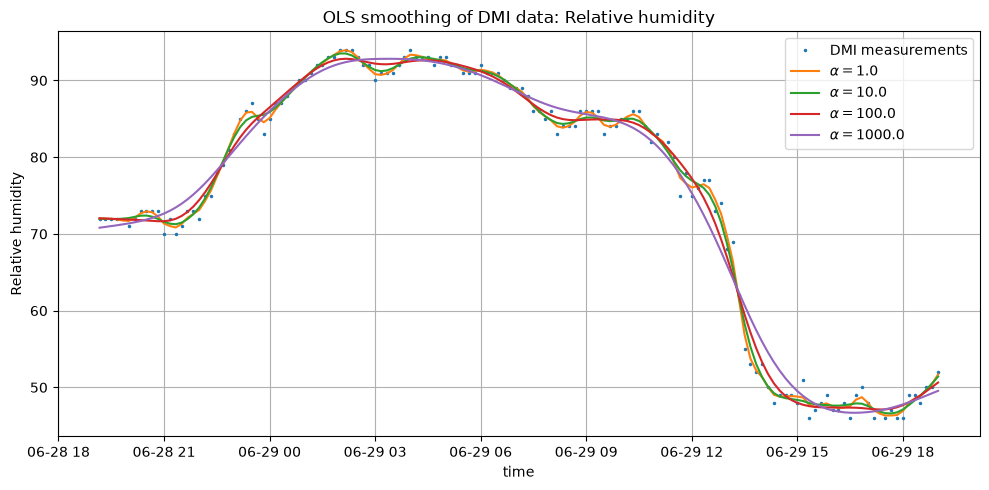

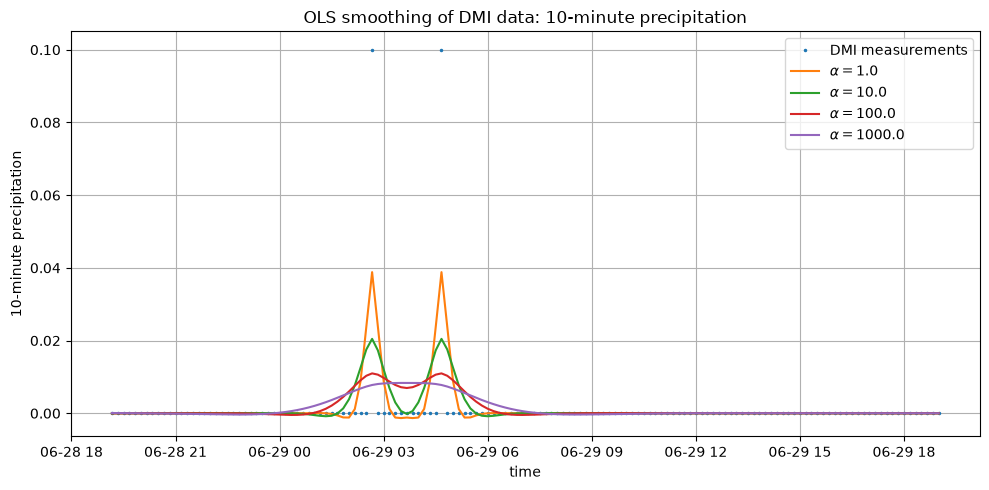

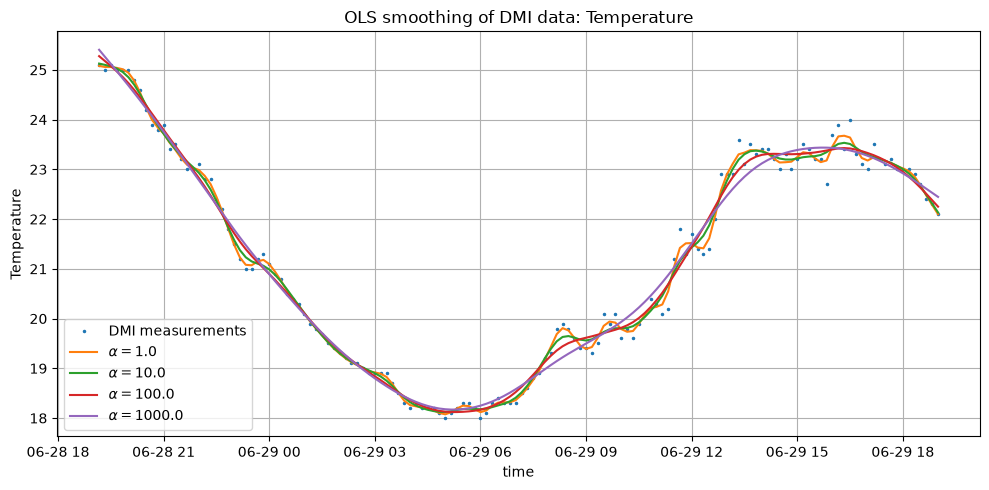

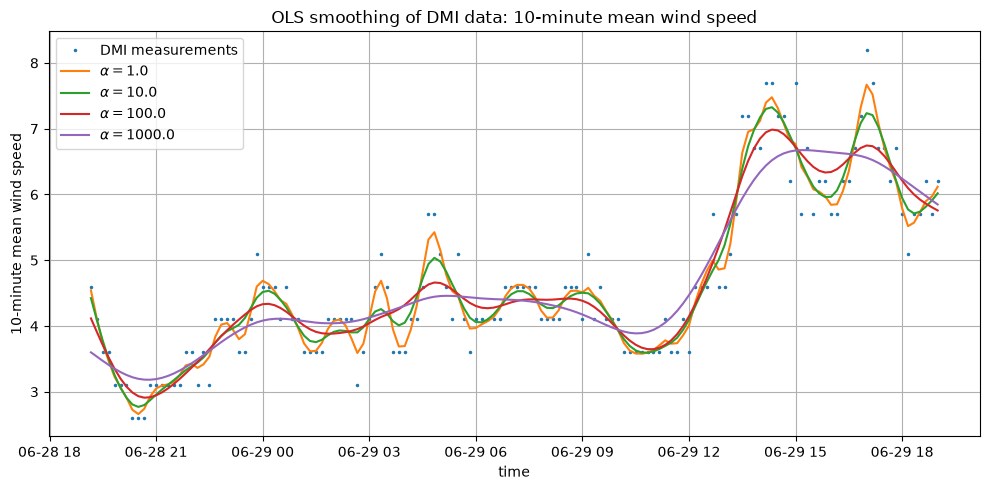

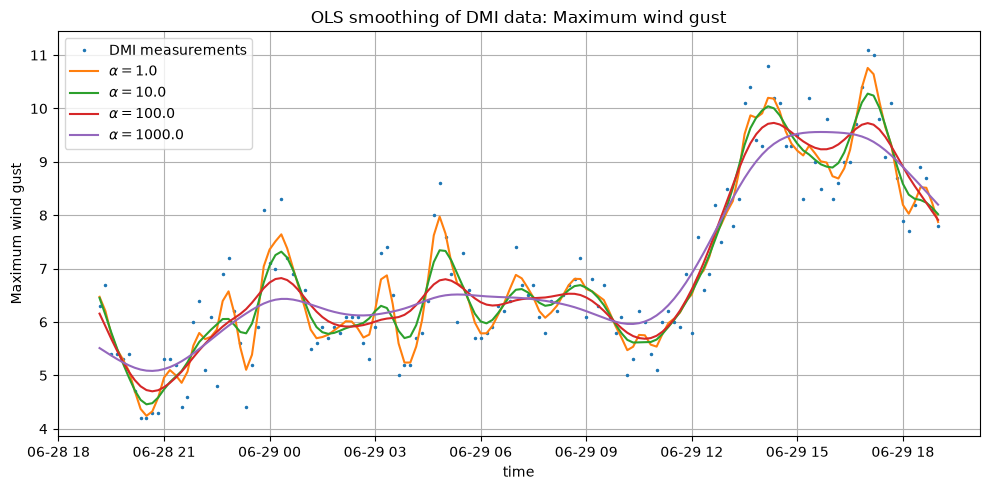

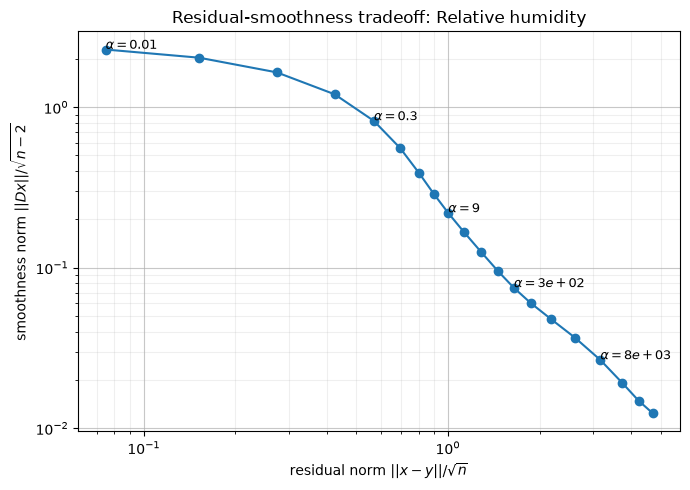

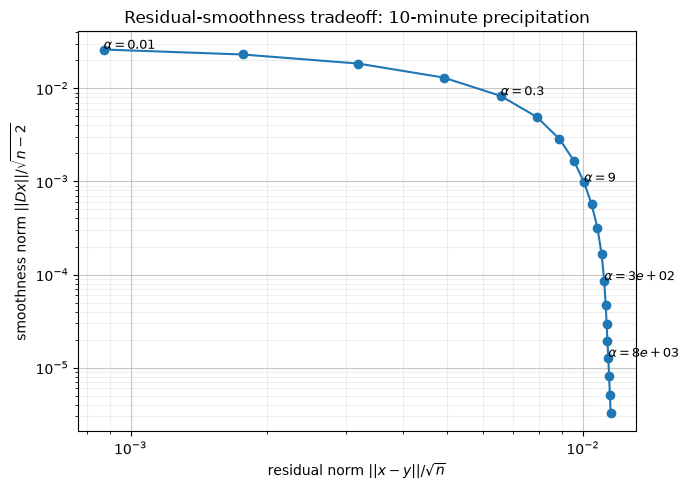

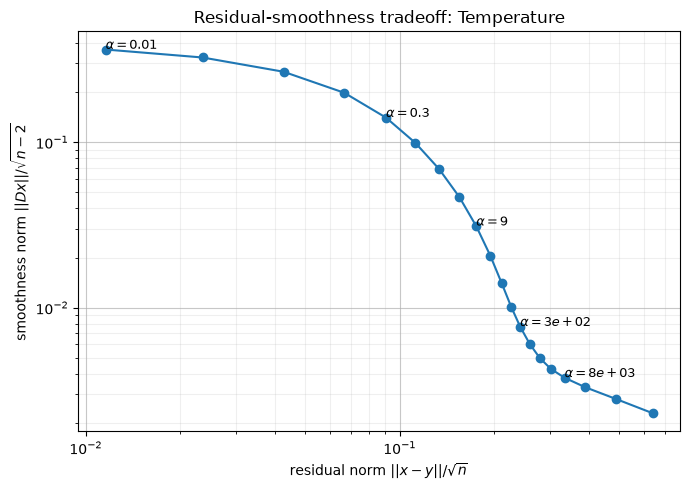

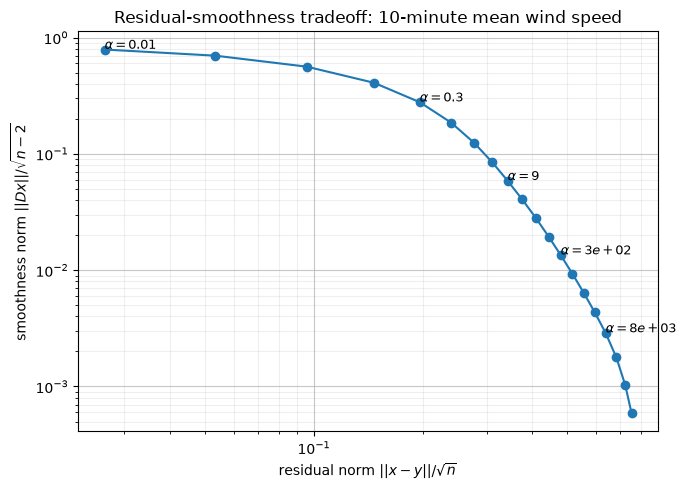

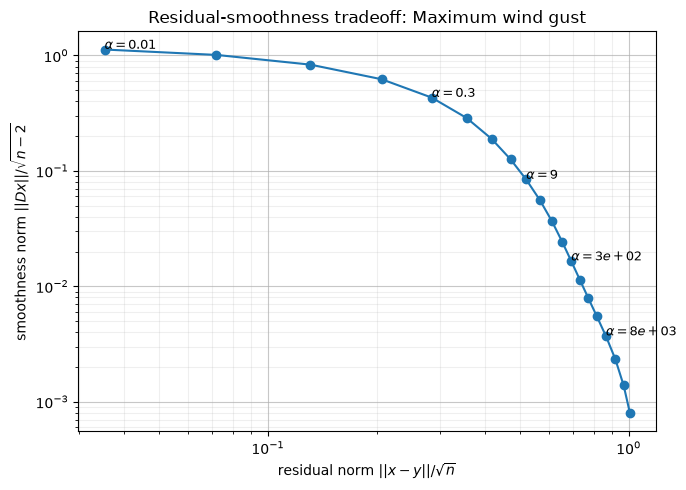

Saved figures in: /home/otterlab2/Pp-nm_VI/PPNM/Exam/Nr_37/figures
Saved result tables in: /home/otterlab2/Pp-nm_VI/PPNM/Exam/Nr_37/results

Saved figures:
 - figures/dmi_smoothing_maximum_wind_gust.png
 - figures/dmi_smoothing_mean_wind_speed_10min.png
 - figures/dmi_smoothing_precipitation_10min.png
 - figures/dmi_smoothing_relative_humidity.png
 - figures/dmi_smoothing_temperature.png
 - figures/limiting_cases_ols_smoothing.png
 - figures/tradeoff_maximum_wind_gust.png
 - figures/tradeoff_mean_wind_speed_10min.png
 - figures/tradeoff_precipitation_10min.png
 - figures/tradeoff_relative_humidity.png
 - figures/tradeoff_temperature.png
 - figures/validation_ols_smoothing.png

Saved result files:
 - results/dmi_smoothed_maximum_wind_gust.csv
 - results/dmi_smoothed_mean_wind_speed_10min.csv
 - results/dmi_smoothed_precipitation_10min.csv
 - results/dmi_smoothed_relative_humidity.csv
 - results/dmi_smoothed_temperature.csv
 - results/dmi_smoothing_summary.csv
 - results/limiting_case_re

In [8]:
from pathlib import Path
from matplotlib.ticker import NullFormatter
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ------------------------------------------------------------
# Output folders
# ------------------------------------------------------------

figure_dir = Path("figures")
result_dir = Path("results")

figure_dir.mkdir(exist_ok=True)
result_dir.mkdir(exist_ok=True)


# ------------------------------------------------------------
# English names for DMI parameters
# ------------------------------------------------------------

english_names = {
    "Luftfugtighed": "Relative humidity",
    "10 minutters nedbør": "10-minute precipitation",
    "Temperatur": "Temperature",
    "10 min. middelvind": "10-minute mean wind speed",
    "Højeste vindstød": "Maximum wind gust",
}

safe_names = {
    "Luftfugtighed": "relative_humidity",
    "10 minutters nedbør": "precipitation_10min",
    "Temperatur": "temperature",
    "10 min. middelvind": "mean_wind_speed_10min",
    "Højeste vindstød": "maximum_wind_gust",
}


# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def get_time_axis(data):
    """
    Return a time axis from the signal DataFrame.

    If a time/date column exists, it is used.
    Otherwise, point number 0, 1, 2, ... is used.
    """
    possible_time_columns = ["time", "Time", "DateTime", "datetime", "date_time", "DatoTid"]

    for column in possible_time_columns:
        if column in data.columns:
            return pd.to_datetime(data[column], errors="coerce")

    return np.arange(len(data))


def roughness_norm(x):
    """
    Measure roughness of the smoothed signal.

    Smaller value means smoother signal.
    """
    D = second_difference_matrix(len(x))
    return np.linalg.norm(D @ x) / np.sqrt(len(x) - 2)


def residual_norm(y, x):
    """
    Measure distance between measured signal y and smoothed signal x.
    """
    return np.linalg.norm(y - x) / np.sqrt(len(y))


# ------------------------------------------------------------
# 1. Save validation figure for artificial signal
# ------------------------------------------------------------

np.random.seed(12345)

n = 120
t = np.linspace(0, 2*np.pi, n)

y_true = (
    0.7*np.sin(t)
    + 0.35*np.sin(2*t - 0.7)
    + 0.25*np.cos(3*t + 0.4)
)

noise = 0.18*np.random.randn(n)
y_noisy = y_true + noise

validation_alphas = [1.0, 10.0, 100.0, 1000.0]

plt.figure(figsize=(9, 5))
plt.plot(t, y_noisy, ".", markersize=4, label="noisy signal")
plt.plot(t, y_true, label="original noise-free signal")

for alpha in validation_alphas:
    x_smooth = smooth_signal(y_noisy, alpha)
    plt.plot(t, x_smooth, label=fr"$\alpha={alpha}$")

plt.xlabel("t")
plt.ylabel("signal")
plt.title("Validation: OLS smoothing for different smoothing parameters")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(figure_dir / "validation_ols_smoothing.png", dpi=300)
plt.show()


# ------------------------------------------------------------
# 2. Save limiting-case figure and results
# ------------------------------------------------------------

alpha_small = 1e-12
alpha_large = 1e8

x_small = smooth_signal(y_noisy, alpha_small)
x_large = smooth_signal(y_noisy, alpha_large)

linear_coeffs = np.polyfit(t, y_noisy, 1)
linear_fit = np.polyval(linear_coeffs, t)

small_alpha_difference = np.max(np.abs(x_small - y_noisy))
large_alpha_difference = np.max(np.abs(x_large - linear_fit))

plt.figure(figsize=(9, 5))
plt.plot(t, y_noisy, ".", markersize=4, label="noisy signal")
plt.plot(t, x_small, label=fr"$\alpha={alpha_small:g}$")
plt.plot(t, x_large, label=fr"$\alpha={alpha_large:g}$")
plt.plot(t, linear_fit, "--", label="linear least-squares fit")

plt.xlabel("t")
plt.ylabel("signal")
plt.title("Limiting cases of OLS smoothing")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(figure_dir / "limiting_cases_ols_smoothing.png", dpi=300)
plt.show()

limiting_results = pd.DataFrame({
    "quantity": [
        "max |x(alpha -> 0) - y|",
        "max |x(alpha -> infinity) - linear fit|",
    ],
    "value": [
        small_alpha_difference,
        large_alpha_difference,
    ],
})

limiting_results.to_csv(result_dir / "limiting_case_results.csv", index=False)


# ------------------------------------------------------------
# 3. Save DMI smoothing figures and smoothed data
# ------------------------------------------------------------

dmi_alphas = [1.0, 10.0, 100.0, 1000.0]

dmi_summary_rows = []

for name, data in signals.items():
    plot_name = english_names.get(name, name)
    file_name = safe_names.get(name, name.replace(" ", "_").lower())

    time = get_time_axis(data)
    y = data["value"].to_numpy(dtype=float)

    plt.figure(figsize=(10, 5))
    plt.plot(time, y, ".", markersize=3, label="DMI measurements")

    output_data = pd.DataFrame({
        "time": time,
        "measurement": y,
    })

    for alpha in dmi_alphas:
        x = smooth_signal(y, alpha)

        plt.plot(time, x, label=fr"$\alpha={alpha}$")

        output_data[f"smoothed_alpha_{alpha:g}"] = x

        dmi_summary_rows.append({
            "parameter": plot_name,
            "alpha": alpha,
            "residual_norm": residual_norm(y, x),
            "smoothness_norm": roughness_norm(x),
            "mean_measurement": np.mean(y),
            "std_measurement": np.std(y),
            "min_measurement": np.min(y),
            "max_measurement": np.max(y),
            "mean_smoothed": np.mean(x),
            "std_smoothed": np.std(x),
            "min_smoothed": np.min(x),
            "max_smoothed": np.max(x),
        })

    plt.xlabel("time")
    plt.ylabel(plot_name)
    plt.title(f"OLS smoothing of DMI data: {plot_name}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(figure_dir / f"dmi_smoothing_{file_name}.png", dpi=300)
    plt.show()

    output_data.to_csv(result_dir / f"dmi_smoothed_{file_name}.csv", index=False)


# ------------------------------------------------------------
# 4. Save residual-smoothness tradeoff figures and data
# ------------------------------------------------------------

alpha_scan = np.logspace(-2, 5, 20)

tradeoff_rows = []

for name, data in signals.items():
    plot_name = english_names.get(name, name)
    file_name = safe_names.get(name, name.replace(" ", "_").lower())

    y = data["value"].to_numpy(dtype=float)

    residuals = []
    roughnesses = []

    for alpha in alpha_scan:
        x = smooth_signal(y, alpha)

        r = residual_norm(y, x)
        s = roughness_norm(x)

        residuals.append(r)
        roughnesses.append(s)

        tradeoff_rows.append({
            "parameter": plot_name,
            "alpha": alpha,
            "residual_norm": r,
            "smoothness_norm": s,
        })

    fig, ax = plt.subplots(figsize=(7, 5))

    ax.loglog(residuals, roughnesses, marker="o")

    for alpha, r, s in zip(alpha_scan[::4], residuals[::4], roughnesses[::4]):
        ax.text(r, s, fr"$\alpha={alpha:.1g}$", fontsize=9)

    ax.set_xlabel(r"residual norm $||x-y||/\sqrt{n}$")
    ax.set_ylabel(r"smoothness norm $||Dx||/\sqrt{n-2}$")
    ax.set_title(f"Residual-smoothness tradeoff: {plot_name}")

    ax.grid(True, which="major", alpha=0.7)
    ax.grid(True, which="minor", alpha=0.2)

    ax.xaxis.set_minor_formatter(NullFormatter())
    ax.yaxis.set_minor_formatter(NullFormatter())

    plt.tight_layout()
    plt.savefig(figure_dir / f"tradeoff_{file_name}.png", dpi=300)
    plt.show()


# ------------------------------------------------------------
# 5. Save summary tables
# ------------------------------------------------------------

dmi_summary = pd.DataFrame(dmi_summary_rows)
tradeoff_summary = pd.DataFrame(tradeoff_rows)

dmi_summary.to_csv(result_dir / "dmi_smoothing_summary.csv", index=False)
tradeoff_summary.to_csv(result_dir / "tradeoff_summary.csv", index=False)

print("Saved figures in:", figure_dir.resolve())
print("Saved result tables in:", result_dir.resolve())

print("\nSaved figures:")
for file in sorted(figure_dir.glob("*.png")):
    print(" -", file)

print("\nSaved result files:")
for file in sorted(result_dir.glob("*.csv")):
    print(" -", file)